# Laboratory 5a: Prepare to Build a Distance Measurement Tool (Floating Pt Numbers and Num. Differentiation)
<font size="6"> Week 12 </font> <br>
<font size="3"> Last updated April 22, 2025 </font>

## <span style="color:orange;"> 00. Content </span>

<font size="5"> Mathematics </font>
- Approximating derivatives using finite difference schemes
- Approximation bias

<font size="5"> Programming Skills </font>
- Number types: int, float
- Use of underscore as a numerical separator
- Vectorized computation

<font size="5"> Embedded Systems </font>
- N/A

## <span style="color:orange;"> 0. Required Hardware </span>

- N/A

<h3 style="background-color:lightblue"> Copy the file `student_info.py` into the folder you are working in, then run this cell to put your name and email into this document.</h3>

In [ ]:
from student_info import show_info
show_info()

## <span style="color:orange;"> 1. Two Types of Numbers in Python </span>

## Integers

One of the benefits of using Python is that it has great support for numbers. This makes it much more friendly for doing math than, for example, Javascript or C. Whole numbers in Python have the type `int`, which is short for Integer. You can check this yourself:

In [ ]:
type(5)

Python `int`s can be as big as you like, positive or negative. It can get a bit cumbersome writing and reading them, and the comma has a special meaning in Python, so you can't use it to separate big integers for legibility:

In [ ]:
123,456,789

That gives us a list of three integers. If you want to refer to the number 123,456,789 you can write it without separations, but it is easier to read if you use the underscore symbol where there would be a comma:

In [ ]:
123_456_789 == 123456789

You can put underscores wherever you like in a number -- python ignores them. You could represent a credit card number, for example:

In [ ]:
3782_8224_6310_005

## Floats

The other type of number was mentioned in Lab 4e, floating point numbers. As explained previously, floats are used to represent non-whole numbers like decimals. However, they do present some error since Python can only store a certain amount of digits. For almost all purposes, this relative error is no trouble at all, and if it is posing a problem then the tool introduced last time, SymPy, can be implemented to avoid this.

### <span style="color:red;"> Exercise 1 </span> (5 pts)

For each of the following constants, look them up on Wikipedia or WolframAlpha and report the relative error in their known values using SI units. If an error is not given, you can assume the absolute error is $\pm 1 $ of the last digit given. Note that some times, the absolute error is given in a concise notation, as described here: https://physics.nist.gov/cgi-bin/cuu/Info/Constants/definitions.html. Compare your answers to the relative error in a floating point number, known as [_machine epsilon_](https://en.wikipedia.org/wiki/Machine_epsilon)
(*Reminder: we are using single precision floats*). Make sure you are using relative error, not absolute error.

 - Mass of an electron
 - Orbital period of the moon (the Sidereal period, specifically)
 - Distance from New York to Los Angeles
 - Freezing point of water at atmospheric pressure

<h3 style="background-color:lightblue"> Write Answers for Exercise 1 Below: </h3>

## <span style="color:orange;"> 2. Troubles with Floating Point Numbers </span>

Precision is usually not a problem with floating point numbers, with one major exception which we will address later. The main issue you will face is when comparing numbers. Check this out:

In [ ]:
for x in range(1, 10):
    if x/10 == 0.1*x:
        print(x)

### <span style="color:red;"> Exercise 2 </span> (5 pts)

Explain why a few numbers are missing from the printout above. Include the python values of `x/10` and `0.1*x` in your explanation, for some values of `x` (make a new code cell printing the relevant values).

<h3 style="background-color:lightblue"> Write Answers for Exercise 2 Below </h3>

There are two main ways to deal with this:

1. Whenever possible, use `>=` or `<=` instead of `==` when comparing floating point numbers. This is usually the best thing to do. For example, if a number is decreasing and you want to know when it hits zero, check if it is positive instead of checking if it's zero. Or, better yet, check if it's less than 0.0001, keeping as much precision as you need for your purpose and no more.

2. Instead of checking if floats are equal, check if they are close to eachother. For example, the builtin function `math.isclose` can do this for you, or you can use the version in numpy if working with arrays. Here is how that might look:

In [ ]:
import math
for x in range(1, 10):
    if math.isclose(x/10, 0.1*x):
        print(x)

In [ ]:
import numpy as np
x = np.arange(1, 10)
print(np.isclose(x/10, 0.1*x))

[ True  True  True  True  True  True  True  True  True]


## <span style="color:orange;"> 3. Catastrophic Cancellation </span>

There is one situation where roundoff error is a really big problem. That is when you are subtracting two numbers which are very close together. This isn't anything special about floating point numbers, this is just a fact about rounding. Here, have a look:

$$
\begin{array}{r}
3.14159265358???\\
-\; 3.14159265332???\\\hline
0.00000000026???
\end{array}
$$

We have used question marks to represent unknown digits, i.e. digits which were lost due to rounding. See how the relative error in the output is much bigger than in either of the inputs: each input has 12 significant figures, but the output has only two significant figures. We can do this a bit more precisely by writing the absolute errors explicitly:

\begin{align*}
3.14159265358??? &\rightarrow 3.14159265358 \pm 5\times 10^{-12}\\
3.14159265332??? &\rightarrow 3.14159265332 \pm 5\times 10^{-12}\\
0.00000000026??? &\rightarrow 0.00000000026 \pm \text{(you figure this one out)}\\
\end{align*}

### <span style="color:red;"> Exercise 3 </span> (5 pts)

What is the absolute error in the output? What are the relative errors of each of the inputs, and what is the relative error of the output?

<h3 style="background-color:lightblue"> Write Answers for Exercise 3 Below </h3>

### <span style="color:red;"> Exercise 4 </span> (25 pts)

### A practical example of catastrophic cancellation

Before continuing, run the following block. This code will be able to check if your code works properly.

In [ ]:
%%sh
wget -q -N https://raw.githubusercontent.com/TheDataScienceLabs/DSLab_Calculus/main/book/labs/5_measure_speeds/a_derivatives/autograder.py
wget -q -N https://raw.githubusercontent.com/TheDataScienceLabs/DSLab_Calculus/main/book/labs/5_measure_speeds/a_derivatives/lab_5a_checker.py

Here we walk you through coding an example where catastrophic cancellation makes a pretty big difference, and something clever you can do to fix it.

__Part 1__ (5 pts)

Write a function which takes the coefficients `a`, `b`, and `c` from a polynomial $ax^2+bx+c$ and gives you a list of the roots. Just apply the standard quadratic formula. For now, you can assume that $b^2-4ac>0$ so you can take the square root, and you can assume `a` is not zero. Have it give the smaller root first (you can use the built in function `sorted` for this).

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 1 Below </h3>

In [ ]:
import lab_5a_checker

def naive_roots(a, b, c):
    # fill in the formula here

    return sorted([x1, x2])

lab_5a_checker.check_naive_roots(naive_roots)

__Part 2__ (2.5 pts)

Factor the polynomial $x^2-1,000,000.000,001 x +1$ exactly, on paper (note the decimal place in `b`). What should the roots be?

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 2 Below </h3>

__Part 3__ (2.5 pts)

Apply your simple root-finding function to this polynomial. What are the relative errors in your computed roots, compared to the true values? Explain why one of these has a larger relative error.

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 3 Below </h3>

In [ ]:
# call your root finding function

Here is a simple technique we can apply to reduce the error. Let's assume for now that `b` is a negative number. So, we get cancellation in the numerator when subtracting $-b$ and $\sqrt{b^2-4ac}$. In this case, just multiply by one in a clever way:

\begin{align*}
\frac{-b-\sqrt{b^2-4ac}}{2a}
&= \frac{-b-\sqrt{b^2-4ac}}{2a} \times \frac{-b+\sqrt{b^2-4ac}}{-b+\sqrt{b^2-4ac}}\\
&= \frac{b^2-(b^2-4ac)}{2a(-b+\sqrt{b^2-4ac})}\\
&= \frac{2c}{-b+\sqrt{b^2-4ac}}
\end{align*}

Since `b` is negative and `-b` is positive, there is no cancellation here! We can use this formula to compute the "-" root, while the original formula will continue to compute the "+" root correctly.

__Part 4__ (5 pts)

Assuming `b` is always negative, rewrite your function to use this formula for one root and the standard formula for the other root. Compute the relative errors on the example above, using your new formula.

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 4 Below </h3>

In [ ]:
# rewrite your function
import lab_5a_checker

def naive_roots(a, b, c):
    # fill in the formula here
    return sorted([x1, x2])

lab_5a_checker.check_improved_naive_roots(naive_roots)

__Part 5__ (5 pts)

Figure out a similar formula which works when `b` is always positive. Use both formulas to write a function to compute the roots which is always accurate, and does not suffer from catastrophic cancellation.

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 5 Below </h3>

In [ ]:
# write a better root finding function
import lab_5a_checker

def naive_roots(a, b, c):
    # fill in the formula here
    return sorted([x1, x2])

lab_5a_checker.check_improved_naive_roots(naive_roots)

__Part 6__ (5 pts)

Finish off your function by adding a special case for if `c` is exactly zero (don't want to divide by zero, after all!). We have provided a test you can use to check your work.

<h3 style="background-color:lightblue"> Write Answers for Exercise 4 Part 6 Below </h3>

In [ ]:
# add special cases for a and c
def roots(a, b, c):
    # fill in the formula here
    return sorted([x1, x2])

lab_5a_checker.check_roots(roots)

This example shows how catastrophic cancellation can occur even in friendly, well-known functions. This also shows that we can usually deal with it, by doing some clever algebra. This is such a common issue that there are now tools available to identify and fix catastrophic cancellation. If you are curious, check out [Herbie](http://herbie.uwplse.org/), which a friend of mine helped to create.

## <span style="color:orange;"> 4. Numerical Differentiation </span>

Now you are prepared to see the major problem we are up against when trying to compute derivatives using floating-point arithmetic. Remember that by definition, the derivative of a function $f(x)$ is

$$
f'(x) = \lim_{h\to 0} \frac{f(x+h)-f(x)}{h}
$$

This suggests a simple way to compute a derivative: pick a really small number $h$, and compute $\frac{f(x+h)-f(x)}{h}$. Since $h$ is just a small but finite number, this is called the *finite difference method*.

### <span style="color:red;"> Exercise 5 </span> (10 pts)

Let's see what happens when we apply this procedure blindly. We will apply this formula for $f(x)=x^2$ at the point $x=4$. The correct derivative should be 8. We will compute the relative error in using the finite difference method, for various values of $h$. It is easy to get a good spread of values for $h$, in a geometric sequence:

In [ ]:
h = np.geomspace(1e-15, 1, 200)

__Part 1__ (5 pts)

Make an array giving approximations to $f'(4)$ for each value of `h`, using the finite difference method. Then, compute the relative error in this approximation using the relative error formula. Tools to check your work are available. You must use arrays and broadcasting to get full credit here.

<h3 style="background-color:lightblue;"> Write Answers for Exercise 5 Part 1 Below </h3>

In [ ]:
approximation =
relative_error =
lab_5a_checker.check_finite_difference(approximation, relative_error)

__Part 2__ (5 pts)

Now that we have computed the relative error, let's inspect it in a plot. We will use a logarithmic scale for the x and y axes, which will help us to compare very different values. Since we are taking a logarithm, we must look at the absolute value of the relative error.

In [ ]:
import matplotlib.pyplot as plt
plt.loglog(h, [abs(err) for err in relative_error])
plt.xlabel('step size $h$')
plt.ylabel('relative error in computing the finite difference')
plt.show()

In light of what you have learned today about catastrophic cancellation, explain the shape of the curve you get. Explain why it is not a good idea to just make $h$ as small as possible. What is the smallest relative error we can achieve using this method?

<h3 style="background-color:lightblue;"> Write Answers for Exercise 5 Part 2 Below </h3>

## <span style="color:orange;"> 5. Finite Difference Schemes </span>

This shows the basic struggle of computing numerical derivatives: the definition of the derivative requires `h` to be infinitely small, but we can't practically make it that small. This isn't just because of catastrophic cancellation, by the way -- often when working with real data you are limited in how fast you can collect it. Hence, our goal will be to find ways to get more accurate estimates of the derivative without just making the step size $h$ tiny. We will consider $h$ to be fixed, and try to get our estimate as good as possible.

### Bias in the forward difference

Let's examine the finite difference method, applied to the function $f(x) = x^3$ at $x=2$. For ease of illustration, let's choose $h=0.5$. Our estimate of $f'(2)$ is

$$
f'(2)\approx \frac{(2+0.5)^3-2^3}{0.5}.
$$

Is this an over-estimate or an under-estimate? Let's draw a picture to help us see.

### <span style="color:red;"> Exercise 6 </span> (2.5 pts)

**Part 1** (2.5 pts)

Find an equation for the tangent line to $y=f(x)$ at $x=2$.

**Part 2** (2.5 pts)

Find an equation for the secant line intersecting $y=f(x)$ at $x=2$ and $x=2.5$.

<h3 style="background-color:lightblue;"> Write Answers for Exercise 6 Below </h3>

Fill in the formulas you found for the secant and tangent lines below.

In [ ]:
x = np.linspace(1,3)
cube = x**3
tangent = #fill in here
secant = #fill in here
plt.plot(x, cube, label="$x^3$")
plt.plot(x, tangent, '--', label="tangent")
plt.plot(x, secant, '--', label="secant")
plt.ylim(0,27)
plt.xlim(1, 3)
plt.legend()
plt.show()

That shows it visually: the slope of the secant line is bigger than the slope of the tangent line. We can see it algebraically too:
\begin{align*}
\frac{(2+0.5)^3-2^3}{0.5}
&=\frac{12(0.5)+6(0.5)^2+(0.5)^3}{0.5}\\
&=12+6(0.5)+(0.5)^2
\end{align*}
The correct derivative is 12, and the other terms (most of all the term $6(0.5)$) are making it too big.

When we choose $h$ to be a positive number, we call that a *forward difference*. What if we try making $h$ negative, doing a so-called *backward difference*? Try that now.

### <span style="color:red;"> Exercise 7 </span> (5 pts)

**Part 1** (2.5 pts)

Create a similar plot to show what happens if $h=-0.5$.

**Part 2** (2.5 pts)

Is the slope of the secant line too big, or too small, in this case? Support your claim using your figure. How is this related to the curvature of the function $f(x)=x^3$?

<h3 style="background-color:lightblue;"> Write Answers for Exercise 7 Part 1 Below </h3>

In [ ]:
x = np.linspace(1,3)
cube = x**3
tangent = #fill in here
secant = #fill in here
plt.plot(x, cube, label="$x^3$")
plt.plot(x, tangent, '--', label="tangent")
plt.plot(x, secant, '--', label="secant")
plt.ylim(0,27)
plt.xlim(1, 3)
plt.legend()
plt.show()

<h3 style="background-color:lightblue;"> Write Answers for Exercise 7 Part 2 Below </h3>

### Correcting the bias

As you have noticed, the forward difference gave us an over-estimate while the backward difference gave an under-estimate. This gives us a clear way to do better: we could average these answers out, which would give us a (hopefully) unbiased answer. Algebraically, this would look something like this:

\begin{align*}
\frac{1}{2}\left[ \frac{f(x+h) - f(x)}{h} + \frac{f(x-h)-f(x)}{-h} \right]
&= \frac{f(x+h)-f(x)-f(x-h) + f(x)}{2h}\\
&= \frac{f(x+h)-f(x-h)}{2h}
\end{align*}

This is the *symmetric difference* scheme. You can think of it as a secant line which doesn't go through a given point, but rather goes through its neighbors.

In [ ]:
x = np.linspace(1,3)
cube = x**3
tangent = 12*(x-2)+8
secant = (2.5**3-1.5**3)*(x-1.5)+1.5**3
plt.plot(x, cube, label="$x^3$")
plt.plot(x, tangent, '--', label="tangent")
plt.plot(x, secant, '--', label="secant")
plt.ylim(0,27)
plt.xlim(1, 3)
plt.legend()
plt.show()

No obvious bias! We can still work out algebraically that it's not exact:
\begin{align*}
\frac{(2+0.5)^3 - (2-0.5)^3}{2*(0.5)} = 12.25
\end{align*}
This is still a slight overestimate. However, it's clearly way better for any given step size $h$. The error gets small really fast, too: if we instead had $h=10^{-9}$, the error would be just $(10^{-9})^2 = 10^{-18}$, which is smaller than the floating-point error. Symmetric difference is better than forward difference!

### <span style="color:red;"> Exercise 8 </span> (5 pts)

Work out the symmetric difference exactly on paper for the function $f(x)=5x^2+3x-7$, for a variable step size $h$, at the point $x=2$. Find the relative error algebraically, and comment on it.

<h3 style="background-color:lightblue;"> Write Answers for Exercise 8 Below </h3>

In [ ]:
l

## <span style="color:orange;"> 6. Finite Differences with unequal step size</span>

So far, we have assumed that the step size $h$ is constant for every value of $x$. However, when we collect data from sensors, this constraint might not always be true.

Consider an interval $a \le x \le b$. Let's divide this interval into eight equal parts. Then $x[0] = a$, $x[7] = b$, and for $i = 1,...,6$, we define $x[i] = a + ih$, where the step size $h$ can be calculated as $h = \frac{b-a}{7}$. See the figure below for an example.

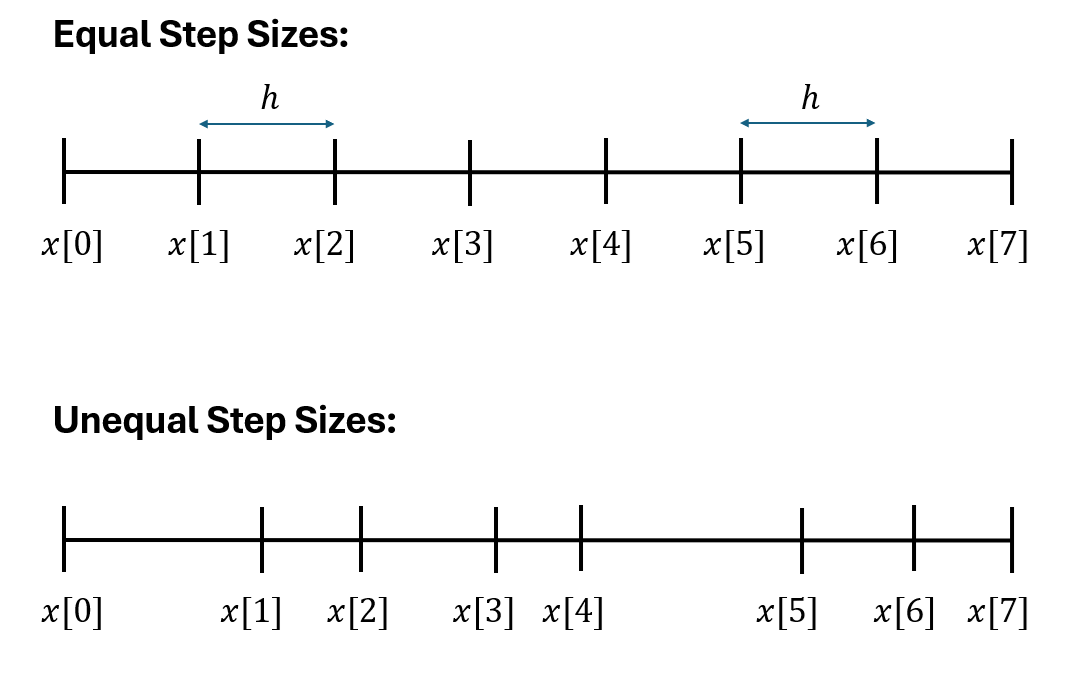

In constrast, let's consider the same interval $a \le x \le b$ and divide it into eight *unequal* parts. Just as before, $x[0] = a$ and $x[7] = b$, but there is no longer a nice formula for each $x[i]$ for $i = 1,...,6$. The step-size now depends on our location along the number line.

Now, when we use finite differences to approximate the derivative, we use the following formula.

\begin{align*}
    f'(x[i]) \approx \frac{f(x[i+1]) - f(x[i])}{x[i+1] - x[i]}
\end{align*}

where $i$ goes from 0, 1, 2, ..., N-2.


### <span style="color:red;"> Exercise 9 </span> (5 pts)

Finding derivative of a single variable function with unequal step size:

(a) Construct an array of values $x$ where $0 \le x \le 2$ and with unequal step sizes. First define a helper array $t$ where $0 \le t \le 1$ with $N$ equally spaced values. Then, we will define the array $x$ by the formula $x = a + (b-a)t^3$.

(a) Let $f(x) = 4x + 5$, and calculate the values of $f(x)$ for $N=10$ and $N=100$.

(b) Use the finite difference formula to approximate the derivative $f'(x)$ for $f(x) = 4x + 5$ for $N = 10$ and $N=100$.

(c) Plot the approximation of the derivative of $f(x)$ for both the values of $N$. It should come out to be a straight line. Note: remember the derivative will have one less datapoint than the original data.


In [ ]:
# Write you answer here

### <span style="color:red;"> Exercise 10 </span> (6 pts)

(a) Repeat the above problem but for the function $f(x) = 2x^2 + 4x + 5$ with the same range for $x$ and definition of $x$ as in Problem 9. (5 pts)

(b) For which value of N did you get a more accurate derivative? (1 pts)

In [ ]:
# Write answer for excersize 10 part (a) below:



<h3 style="background-color:lightblue;"> Write Answers for Exercise 10 Part b Below </h3>

## Second-order accurate scheme for unequal step size

As we saw before, we can get a more accurate approximation to the derivative by using a different finite difference scheme. This is true even when the step-sizes are unequal.

Below is the second-order accurate finite difference scheme for unequal step-sizes. It is derived using Taylor series approximations. Like before, we will take a (weighted) average of a forward difference and a backward-difference. This requires us to know the step size on the left and right of a given point where we want to evaluate.

\begin{align*}
    f'(x_i) \approx -\frac{h_{+}}{h_{-}(h_{-} + h_{+})}f(x_{i-1}) + \frac{h_{+} - h_{-}}{h_{+}(h_{-} + h_{+})}f(x_{i}) + \frac{h_{-}}{h_{+}(h_{-} + h_{+})} f(x_{i+1})
\end{align*}

where $h_{-} =x_{i} - x_{i-1}$ is the difference on the left, and $h_{+} = x_{i+1} - x_{i}$ is the difference on the right.

### <span style="color:red;"> Exercise 11 </span> (5 pts)

Repeat the above problem but for the function $f(x) = 2x^2 + 4x + 5$ by using the second-order scheme.

Caution: While iterating remeber to take proper care for the limits of $x_i$ to avoid running out of memory of the array defining $x$.

In [ ]:
# Write answer for excersize 11 below:
